# PCA - Principle Component Analysis

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = [
    [2, 1],
    [4, 3],
    [6, 5],
    [8, 7]
]

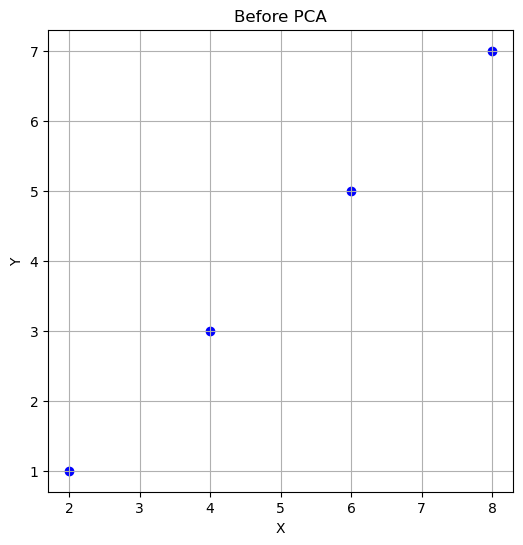

In [27]:
data = np.array(data)
plt.figure(figsize=(6, 6))
plt.scatter(data[:, 0], data[:, 1], color='blue', label='Original Data')
plt.title("Before PCA")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

## Compute mean

In [3]:
n = len(data)
mean_x = sum(p[0] for p in data) / n
mean_y = sum(p[1] for p in data) / n

## Center the data

Because each feature has different means which may cause trouble calculating the covariance matrix which is the backbone of PCA, so we will center each feature to a common center so the matrix calculation makes sense i.e. center it to 0.

In [5]:
centered = [
    [ p[0] - mean_x , p[1] - mean_y ]
    for p in data
]
centered

[[-3.0, -3.0], [-1.0, -1.0], [1.0, 1.0], [3.0, 3.0]]

## Compute Covariance Matrix

variance as we studied earlier means squared distance from the mean value 

for each value take square from the centered (mean subtracted) value add it and divide it with the length which will in turn give you the variance (by taking the average)

In [30]:
cov_xx = sum(p[0]**2 for p in centered) / n
cov_yy = sum(p[1]**2 for p in centered) / n
cov_xy = sum(p[0]*p[1] for p in centered) / n

cov_matrix = [
    [cov_xx,cov_xy],
    [cov_xy,cov_yy]
]
cov_matrix

[[np.float64(5.0), np.float64(5.0)], [np.float64(5.0), np.float64(5.0)]]

## Find EigenVectors of Covariance

In [31]:
trace = cov_xx + cov_yy
det = cov_xx*cov_yy - cov_xy**2

descriminant = trace**2 - 4*det

lambda1 = (trace + descriminant**0.5) / 2
lambda2 = (trace - descriminant**0.5) / 2
def eigenvector(eigvalue):
    if cov_xy != 0:
        x = 1
        y = -(cov_xx - eigvalue) / cov_xy
    else :
        if eigvalue == cov_xx:
            x,y = 1,0
        else:
            x,y = 0,1
    return [x,y]

if lambda1 > lambda2:
    pc1 = eigenvector(lambda1)
    pc2 = eigenvector(lambda2)
else:
    pc1 = eigenvector(lambda1)
    pc2 = eigenvector(lambda2)

In [32]:
# Normalize the direction
#Normalization means making the eigenvector’s length equal to 1, so it represents only a direction, not magnitude.
#∥v∥=x2+y2
def magnitude(v):
    return (v[0]**2 + v[1]**2) ** 0.5
def normalize(v):
    mag = magnitude(v)
    return [v[0] / mag, v[1] / mag]

pc1 = normalize(pc1)
pc2 = normalize(pc2)

## Projection

In [33]:
def dot(a, b):
    return sum(a[i]*b[i] for i in range(len(a)))

pca_result = [dot(p, pc1) for p in centered]
print(pca_result)

[np.float64(-4.242640687119285), np.float64(-1.414213562373095), np.float64(1.414213562373095), np.float64(4.242640687119285)]


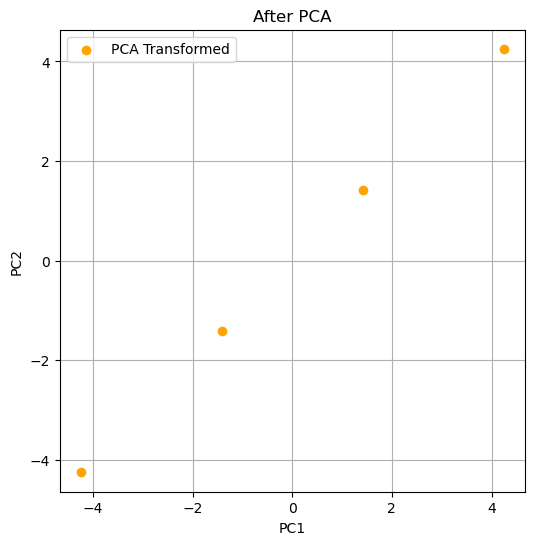

In [39]:
pca_result = np.array(pca_result)
plt.figure(figsize=(6, 6))
plt.scatter(pca_result,pca_result, color='orange', label='PCA Transformed')
plt.title("After PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()


# Using Numpy

Original shape: (6, 4)
Reduced shape: (6, 2)
Explained variance: [0.94110742 0.04743012]


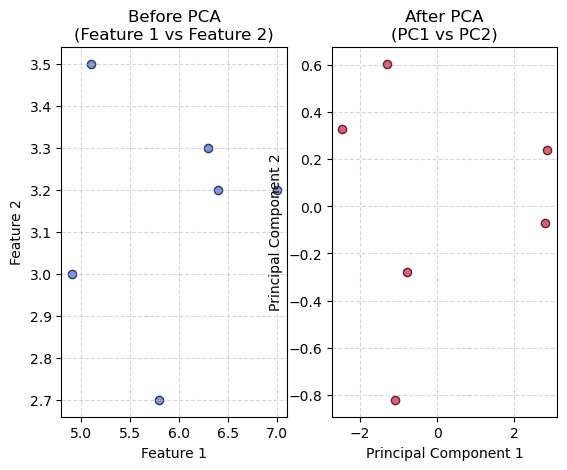

In [47]:
# Read data
data = pd.read_csv("sample_PCA.csv")

# Before PCA
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c='royalblue', edgecolors='k', alpha=0.7)
plt.title("Before PCA\n(Feature 1 vs Feature 2)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, linestyle='--', alpha=0.5)

# Convert to NumPy array (skipping non-numeric columns if any).And we only need input columns
X = data.drop(columns=['target']).select_dtypes(include=[np.number]).to_numpy()

# Continue with PCA...
X_centered = X - np.mean(X, axis=0)
cov_matrix = np.cov(X_centered, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
sorted_idx = np.argsort(eigenvalues)[::-1]
X_reduced = X_centered @ eigenvectors[:, sorted_idx[:2]]

print("Original shape:", X.shape)
print("Reduced shape:", X_reduced.shape)
print("Explained variance:", eigenvalues[sorted_idx][:2] / np.sum(eigenvalues))

plt.subplot(1, 2, 2)
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c='crimson', edgecolors='k', alpha=0.7)
plt.title("After PCA\n(PC1 vs PC2)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, linestyle='--', alpha=0.5)

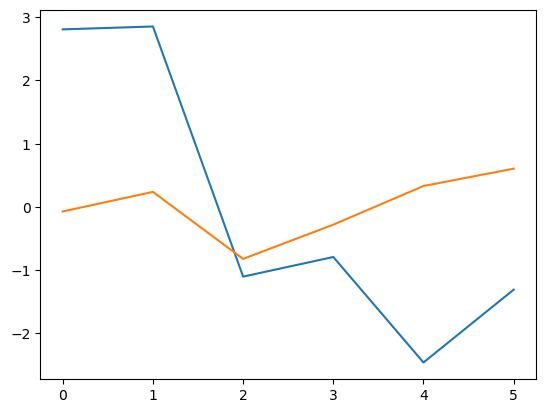

In [52]:
plt.plot(X_reduced)